In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess

Set constants and load data

In [3]:
# set variables
threshold = 0.25
look_back = 2
look_forward_time = 8

In [4]:
# set file path
# Make sure there are three folders: Code, Data, Results to read from and write to
file_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie"
data_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie/Data/Time_Dependent_All/No Refractory"
data_save_path = os.path.join(data_path, f'Threshold_{int(threshold * 100)}_Lookforward_{look_forward_time}_Lookback_{look_back}')
os.makedirs(data_save_path, exist_ok=True)

In [5]:
# # load no exclusion data
# result = pyreadr.read_r("C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie/Data/no.exclusions.patient.data.RData")
# patient_data = result["patient.data"]
# print(patient_data.shape)

In [5]:
# load data
with open(f"{file_path}/Data/patient.data.pkl", 'rb') as f:
    data = pickle.load(f)
patient_data = data['patient_data']
print(patient_data.shape)

(4429852, 27)


Analysis

In [6]:
# create a list of dfs, 1 df per LCSN
patient_df_list = [group.reset_index(drop=True) for _, group in patient_data.groupby('LCSN')]
# remove dfs where patient doesn't have x hours of data
patient_df_list_filtered = [df for df in patient_df_list if len(df) >= (look_back * 4 + 1)]

In [7]:
# at each time point, look at time frame x hours back, look forward y hours to see outcome
# track max prediction in past x hours, and outcome in next y hours
# start from time point x * 4 (since we need to look back x hours)
# loop through list of dfs
new_patient_df_list = []
for patient_df in tqdm(patient_df_list_filtered):
    max_pred_list = []
    outcome_list = []

    for time_point in patient_df['time.point']:
        # start from time point x (since look back x hours), make sure sep outcome at the time is not 1
        if (time_point >= (look_back * 4)) and (patient_df['time.sep3.outcome'].iloc[time_point] != 1):
            max_pred = patient_df.iloc[(time_point - (look_back * 4)):time_point]['model.score'].max()
            outcome = (patient_df.iloc[time_point:time_point + (look_forward_time * 4)]['time.sep3.outcome'] == 1).any()
            max_pred_list.append(max_pred)
            outcome_list.append(outcome)
        else:
            # mark -1 if N/A
            max_pred_list.append(-1)
            outcome_list.append(-1)
    
    # create new columns of max model score in past x hours and outcome in x hours at each point
    new_df = patient_df.copy()
    new_df['look_back_max'] = max_pred_list
    new_df['look_forward_outcome'] = outcome_list
    new_patient_df_list.append(new_df)

100%|██████████| 26520/26520 [07:29<00:00, 58.94it/s] 


In [8]:
# recombine dfs, save
combined_df = pd.concat(new_patient_df_list, ignore_index=True)
# remove all rows where look_back_max or look_forward_outcome are -1 (only analyze on time points with valid look back max score and look forward outcome)
combined_df_filtered = combined_df[~((combined_df['look_back_max'] == -1) & (combined_df['look_forward_outcome'] == -1))]

In [10]:
# save
#combined_df_filtered.to_csv(os.path.join(data_save_path, 'Time_Dependent_Data.csv'), index = False)

GO FROM HERE FOR PLOT

In [9]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess

In [12]:
# # set variables if not done above
# threshold = 0.25
# look_back = 2
# look_forward_time = 8

In [13]:
# # set file path if not done above
# # Make sure there are three folders: Code, Data, Results to read from and write to
# file_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie"
# data_path = "C:/Users/jenan/OneDrive - Tufts Medicine/code/EDSValidation_Jennie/Data/Time_Dependent_All/No Refractory"
# data_save_path = os.path.join(data_path, f'Threshold_{int(threshold * 100)}_Lookforward_{look_forward_time}_Lookback_{look_back}')

In [14]:
# load data if not loaded above
# combined_df_filtered = pd.read_csv(os.path.join(data_save_path, 'Time_Dependent_Data.csv'))

In [10]:
# add new col for "prediction" if look_back_max is >= threshold of z
combined_df_filtered['time_dependent_prediction'] = (combined_df_filtered['look_back_max'] >= threshold).astype(int)

C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\100695121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['time_dependent_prediction'] = (combined_df_filtered['look_back_max'] >= threshold).astype(int)


In [11]:
# replace true in look_forward_outcome with 1 and false with 0
combined_df_filtered['look_forward_outcome'] = combined_df_filtered['look_forward_outcome'].astype(int)

C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\1141360750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_filtered['look_forward_outcome'] = combined_df_filtered['look_forward_outcome'].astype(int)


In [12]:
# create list of dfs grouped by time point
time_point_df_list = [group for _, group in combined_df_filtered.groupby('time.point')]

In [ ]:
# # get metrics at each time point no bootstrapping
# # prediction = alarm went off (max score in past x hours is >= threshold)
# # outcome = if there was sepsis in the next 8 hours or not
# import warnings
# from sklearn.exceptions import UndefinedMetricWarning

# warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# # loop through each time point
# time_point = []
# incidence = []
# tp = []
# fp = []
# tn = []
# fn = []
# auc = []
# sensitivity = []
# specificity = []
# ppv = []
# npv = []
# at_risk = []

# for df in tqdm(time_point_df_list):
#     predictions = df['time_dependent_prediction']
#     outcomes = df['look_forward_outcome']

#     time_point.append(df['time.point'].iloc[0])

#     incidence.append(np.mean(outcomes) * 100)
#     tp_val = np.sum((outcomes == 1) & (predictions == 1))  
#     fp_val = np.sum((outcomes == 0) & (predictions == 1))  
#     tn_val = np.sum((outcomes == 0) & (predictions == 0))  
#     fn_val = np.sum((outcomes == 1) & (predictions == 0))  
#     tp.append(tp_val)
#     fp.append(fp_val)
#     tn.append(tn_val)
#     fn.append(fn_val)

#     auc_value = roc_auc_score(outcomes, predictions)
#     auc.append(auc_value)

#     sensitivity_value = tp_val / (tp_val + fn_val) if tp_val + fn_val > 0 else 0
#     sensitivity.append(sensitivity_value)
#     specificity_value = tn_val / (tn_val + fp_val) if tn_val + fp_val > 0 else 0
#     specificity.append(specificity_value)

#     ppv_value = tp_val / (tp_val + fp_val) if tp_val + fp_val > 0 else 0
#     ppv.append(ppv_value)
#     npv_value = tn_val / (tn_val + fn_val) if tn_val + fn_val > 0 else 0
#     npv.append(npv_value)

#     at_risk.append(len(df))

100%|██████████| 10138/10138 [00:17<00:00, 583.99it/s]


In [21]:
# bootstrapping
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

n_boot = 10  # increase in real use (e.g., 200–1000)

time_point = []

# existing metrics
auc_boot = []
sens_boot = []
spec_boot = []
ppv_boot = []
npv_boot = []

# NEW metrics
incidence_boot = []
tp_boot = []
fp_boot = []
tn_boot = []
fn_boot = []
at_risk_boot = []

for df in tqdm(time_point_df_list):

    predictions = df['time_dependent_prediction'].values
    outcomes = df['look_forward_outcome'].values

    time_point.append(df['time.point'].iloc[0])

    n = len(df)

    auc_samples = []
    sens_samples = []
    spec_samples = []
    ppv_samples = []
    npv_samples = []

    incidence_samples = []
    tp_samples = []
    fp_samples = []
    tn_samples = []
    fn_samples = []
    at_risk_samples = []

    for _ in range(n_boot):

        idx = np.random.randint(0, n, n)  # bootstrap resample

        y_pred = predictions[idx]
        y_true = outcomes[idx]

        # confusion matrix
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        # store raw counts
        tp_samples.append(tp)
        fp_samples.append(fp)
        tn_samples.append(tn)
        fn_samples.append(fn)

        # incidence
        incidence = np.mean(y_true)
        incidence_samples.append(incidence)

        # at risk (bootstrap sample size)
        at_risk_samples.append(len(y_true))

        # AUC
        try:
            auc_val = roc_auc_score(y_true, y_pred)
        except ValueError:
            auc_val = np.nan

        auc_samples.append(auc_val)

        # derived metrics
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

        sens_samples.append(sens)
        spec_samples.append(spec)
        ppv_samples.append(ppv)
        npv_samples.append(npv)

    # store bootstrap distributions
    auc_boot.append(auc_samples)
    sens_boot.append(sens_samples)
    spec_boot.append(spec_samples)
    ppv_boot.append(ppv_samples)
    npv_boot.append(npv_samples)

    incidence_boot.append(incidence_samples)
    tp_boot.append(tp_samples)
    fp_boot.append(fp_samples)
    tn_boot.append(tn_samples)
    fn_boot.append(fn_samples)
    at_risk_boot.append(at_risk_samples)

100%|██████████| 10138/10138 [00:25<00:00, 401.99it/s]


In [34]:
def ci(x, low=2.5, high=97.5):
    x = np.array(x, dtype=float)
    return np.nanpercentile(x, low), np.nanpercentile(x, high)

summary = []

for i, tp in enumerate(time_point):
    auc_ci_low, auc_ci_high = ci(auc_boot[i])
    sens_ci_low, sens_ci_high = ci(sens_boot[i])
    spec_ci_low, spec_ci_high = ci(spec_boot[i])
    ppv_ci_low, ppv_ci_high = ci(ppv_boot[i])
    npv_ci_low, npv_ci_high = ci(npv_boot[i])
    inc_ci_low, inc_ci_high = ci(incidence_boot[i])
    tp_ci_low, tp_ci_high = ci(tp_boot[i])
    fp_ci_low, fp_ci_high = ci(fp_boot[i])
    tn_ci_low, tn_ci_high = ci(tn_boot[i])
    fn_ci_low, fn_ci_high = ci(fn_boot[i])
    at_risk_ci_low, at_risk_ci_high = ci(at_risk_boot[i])

    summary.append({
        "Time Point": tp,

        # main metrics
        "AUC": np.nanmean(auc_boot[i]),
        "AUC CI Low": auc_ci_low,
        "AUC CI High": auc_ci_high,

        "Sensitivity": np.nanmean(sens_boot[i]),
        "Sensitivity CI Low": sens_ci_low,
        "Sensitivity CI High": sens_ci_high,

        "Specificity": np.nanmean(spec_boot[i]),
        "Specificity CI Low": spec_ci_low,
        "Specificity CI High": spec_ci_high,

        "PPV": np.nanmean(ppv_boot[i]),
        "PPV CI Low": ppv_ci_low,
        "PPV CI High": ppv_ci_high,

        "NPV": np.nanmean(npv_boot[i]),
        "NPV CI Low": npv_ci_low,
        "NPV CI High": npv_ci_high,

        # incidence + counts
        "Incidence": np.nanmean(incidence_boot[i]),
        "Incidence CI Low": inc_ci_low,
        "Incidence CI High": inc_ci_high,

        "TP": np.nanmean(tp_boot[i]),
        "TP CI Low": tp_ci_low,
        "TP CI High": tp_ci_high,

        "FP": np.nanmean(fp_boot[i]),
        "FP CI Low": fp_ci_low,
        "FP CI High": fp_ci_high,

        "TN": np.nanmean(tn_boot[i]),
        "TN CI Low": tn_ci_low,
        "TN CI High": tn_ci_high,

        "FN": np.nanmean(fn_boot[i]),
        "FN CI Low": fn_ci_low,
        "FN CI High": fn_ci_high,

        # at risk
        "At Risk": np.nanmean(at_risk_boot[i]),
        "At Risk CI Low": at_risk_ci_low,
        "At Risk CI High": at_risk_ci_high,
    })

c:\Users\jenan\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\3155054506.py:24: RuntimeWarning: Mean of empty slice
  "AUC": np.nanmean(auc_boot[i]),
C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\3155054506.py:28: RuntimeWarning: Mean of empty slice
  "Sensitivity": np.nanmean(sens_boot[i]),
C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\3155054506.py:36: RuntimeWarning: Mean of empty slice
  "PPV": np.nanmean(ppv_boot[i]),


In [ ]:
results_df = pd.DataFrame(summary)

In [ ]:
# # get df of results
# results_df = pd.DataFrame({
#     'Time Point': time_point,
#     'Incidence': incidence,
#     'TP': tp,
#     'FP': fp,
#     'TN': tn,
#     'FN': fn,
#     'AUC': auc,
#     'Sensitivity': sensitivity,
#     'Specificity': specificity,
#     'PPV': ppv,
#     'NPV': npv,
#     'At Risk': at_risk
# })

In [30]:
# reorder results df
results_df.sort_values(by='time_point', ascending=True, inplace=False)
results_df

,time_point,auc_mean,auc_ci,sens_mean,sens_ci,spec_mean,spec_ci,ppv_mean,ppv_ci,npv_mean,...,tp_mean,tp_ci,fp_mean,fp_ci,tn_mean,tn_ci,fn_mean,fn_ci,at_risk_mean,at_risk_ci
0,8,0.731301,"(0.7124600298375751, 0.7468741840315991)",0.592780,"(0.5575984833384674, 0.6267149457970499)",0.869823,"(0.8665924733252917, 0.8749959306035139)",0.054659,"(0.04920057453884544, 0.05957092907194863)",0.994087,...,196.8,"(178.575, 207.775)",3406.2,"(3268.25, 3490.425)",22759.6,"(22668.8, 22876.875)",135.4,"(117.575, 153.2)",26498.0,"(26498.0, 26498.0)"
1,9,0.714524,"(0.6975811798875303, 0.7391527685188033)",0.519471,"(0.4857554497619644, 0.5700368954480797)",0.909578,"(0.9079380071607601, 0.9122123781013497)",0.065626,"(0.06176389886565255, 0.0709303258166634)",0.993579,...,158.2,"(149.0, 173.65)",2252.0,"(2186.9, 2292.325)",22653.4,"(22607.475, 22724.4)",146.4,"(129.9, 159.55)",25210.0,"(25210.0, 25210.0)"
2,10,0.701659,"(0.67862496404073, 0.7267008471082621)",0.481071,"(0.4353524436090226, 0.5319027714154833)",0.922246,"(0.9207900453689497, 0.9243949125466153)",0.069830,"(0.06287996978452398, 0.07811253160076916)",0.993214,...,138.2,"(123.675, 157.325)",1839.7,"(1789.35, 1874.95)",21821.0,"(21791.675, 21884.3)",149.1,"(132.9, 169.975)",23948.0,"(23948.0, 23948.0)"
3,11,0.690825,"(0.6728279795903943, 0.7095861918208438)",0.443299,"(0.406021940056631, 0.4825801282051282)",0.938351,"(0.9349664639426303, 0.9398288478003454)",0.079200,"(0.06562426205174915, 0.09520710774265842)",0.992991,...,119.3,"(95.35, 147.175)",1384.2,"(1352.45, 1459.4750000000001)",21068.8,"(20982.075, 21129.7)",148.7,"(139.45, 159.875)",22721.0,"(22721.0, 22721.0)"
4,12,0.689040,"(0.6653358115956753, 0.7168724200893187)",0.433230,"(0.3886754618873769, 0.48846662885233505)",0.944851,"(0.9413158301740705, 0.9481918501335606)",0.084584,"(0.07789790773726472, 0.09874197092630156)",0.992976,...,108.4,"(97.675, 122.55)",1174.3,"(1102.8, 1248.2)",20119.0,"(20021.6, 20183.425)",142.3,"(122.675, 166.85)",21544.0,"(21544.0, 21544.0)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10133,10141,NaN,"(nan, nan)",NaN,"(nan, nan)",1.000000,"(1.0, 1.0)",NaN,"(nan, nan)",1.000000,...,0.0,"(0.0, 0.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)"
10134,10142,NaN,"(nan, nan)",NaN,"(nan, nan)",1.000000,"(1.0, 1.0)",NaN,"(nan, nan)",1.000000,...,0.0,"(0.0, 0.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)"
10135,10143,NaN,"(nan, nan)",NaN,"(nan, nan)",1.000000,"(1.0, 1.0)",NaN,"(nan, nan)",1.000000,...,0.0,"(0.0, 0.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)"
10136,10144,NaN,"(nan, nan)",NaN,"(nan, nan)",1.000000,"(1.0, 1.0)",NaN,"(nan, nan)",1.000000,...,0.0,"(0.0, 0.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)",0.0,"(0.0, 0.0)",1.0,"(1.0, 1.0)"


In [31]:
# save
results_df.to_csv(os.path.join(data_save_path, 'Time_dependent_metric_results.csv'), index = False)

In [33]:
# subset df for 4 days, set legend to be in days
subset_results_df = results_df[results_df['time_point'] <= 336]
subset_results_df['Time Point Days'] = subset_results_df['time_point'] / 96

C:\Users\jenan\AppData\Local\Temp\ipykernel_15092\605663346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_results_df['Time Point Days'] = subset_results_df['time_point'] / 96


In [32]:
days = [8, 48, 96, 144, 192, 240, 288, 336]
table_df = subset_results_df[subset_results_df['Time Point'].isin(days)][['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']]
table_df[['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']] = table_df[['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN']].round(2)
table_df = table_df.T

In [33]:
def check_nans_in_columns(df, columns):
    for col in columns:
        n_missing = df[col].isna().sum()
        print(f"Column '{col}' has {n_missing} missing values (NaNs)")
cols_to_check = ['Time Point Days', 'Incidence', 'AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
check_nans_in_columns(subset_results_df, cols_to_check)

Column 'Time Point Days' has 0 missing values (NaNs)
Column 'Incidence' has 0 missing values (NaNs)
Column 'AUC' has 0 missing values (NaNs)
Column 'Sensitivity' has 0 missing values (NaNs)
Column 'Specificity' has 0 missing values (NaNs)
Column 'PPV' has 0 missing values (NaNs)
Column 'NPV' has 0 missing values (NaNs)


In [34]:
subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')

C:\Users\jenan\AppData\Local\Temp\ipykernel_16756\724104491.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')
C:\Users\jenan\AppData\Local\Temp\ipykernel_16756\724104491.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_results_df['AUC'] = subset_results_df['AUC'].fillna(method='ffill')


In [35]:
subset_results_df_to_smooth = subset_results_df.copy()

In [36]:
# LOWESS SMOOTHING FOR EACH COL BASED ON TIME POINT DAYS X
def apply_lowess_multiple(df, x_col, y_cols, frac):
    for col in y_cols:
        smoothed = lowess(df[col], df[x_col], frac)
        df[col] = smoothed[:, 1]
    return df
subset_results_df_smoothed = apply_lowess_multiple(subset_results_df_to_smooth, 'Time Point Days', ['Incidence', 'AUC', 'Sensitivity', 'Specificity', 'PPV', 'NPV'], 0.15)

C:\Users\jenan\AppData\Local\Temp\ipykernel_16756\250427948.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


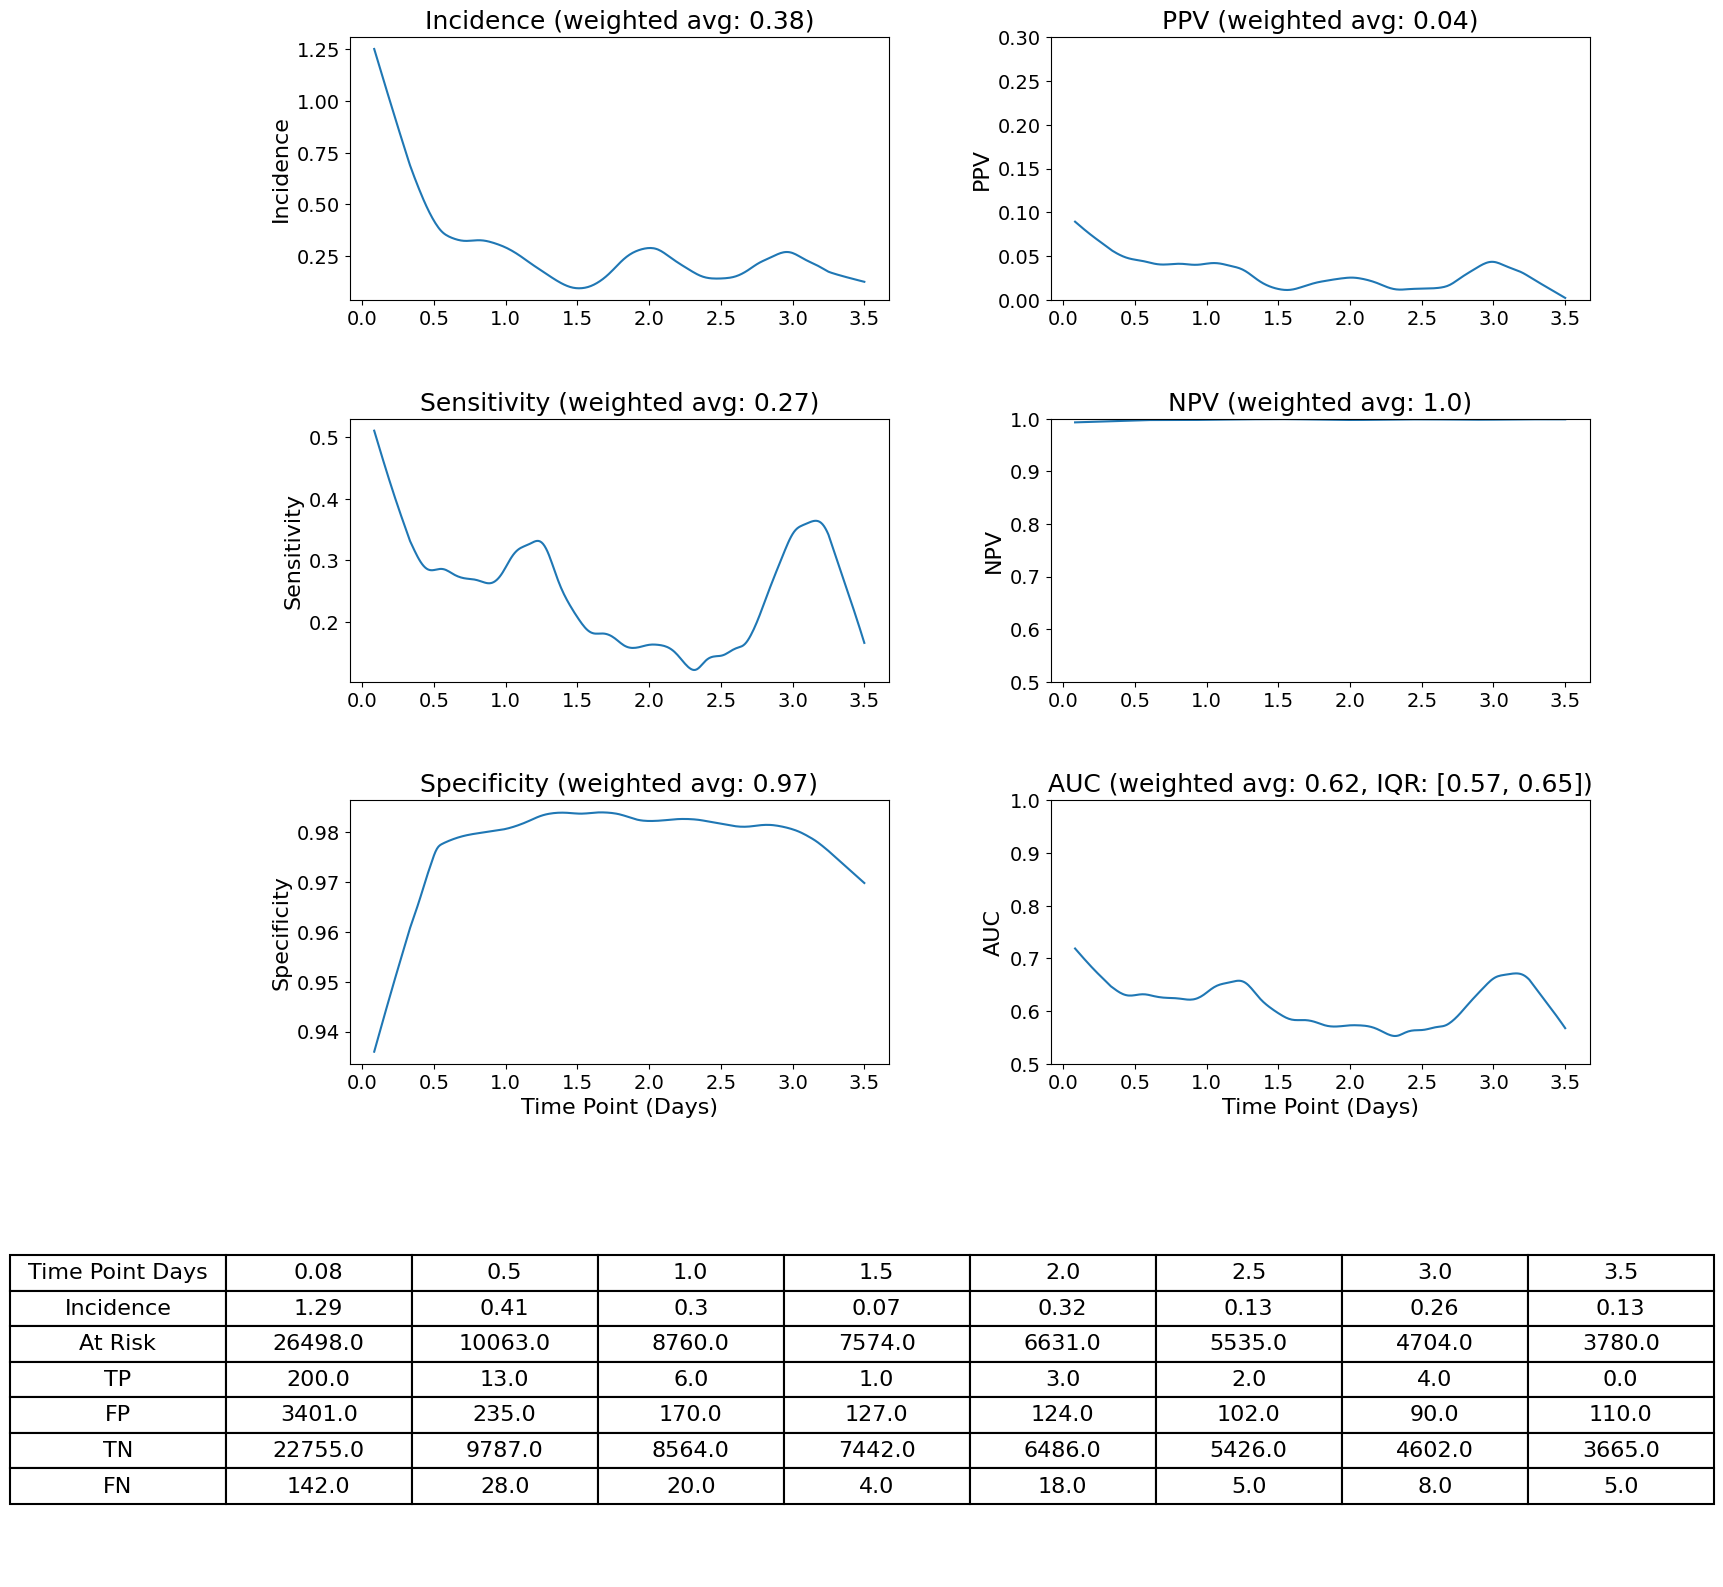

In [38]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Base font sizes
label_fontsize = 16
title_fontsize = 18
tick_fontsize = 14
table_fontsize = 16

# Figure size: wider to match table
fig = plt.figure(figsize=(16, 20))

# GridSpec: 4 rows, 2 columns
# height_ratios: 3 rows of plots, 1 row for table (taller)
# width_ratios: both columns equal width
gs = GridSpec(4, 2, figure=fig, height_ratios=[1, 1, 1, 1.5], width_ratios=[1, 1], hspace=0.4, wspace=0.3)

# ---- Create axes ----
# Left column plots
ax_inc = fig.add_subplot(gs[0, 0])
ax_sens = fig.add_subplot(gs[1, 0], sharex=ax_inc)
ax_spec = fig.add_subplot(gs[2, 0], sharex=ax_inc)

# Right column plots
ax_ppv = fig.add_subplot(gs[0, 1], sharex=ax_inc)
ax_npv = fig.add_subplot(gs[1, 1], sharex=ax_inc)
ax_auc = fig.add_subplot(gs[2, 1], sharex=ax_inc)

# Bottom table spanning both columns
ax_table = fig.add_subplot(gs[3, :])

# ---- Left column ----
ax_inc.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['Incidence'])
ax_inc.set_ylabel('Incidence', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Incidence'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_inc.set_title(f'Incidence (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_inc.tick_params(axis='both', labelsize=tick_fontsize)

ax_sens.plot(subset_results_df_smoothed['Time Point Days'],
             subset_results_df_smoothed['Sensitivity'])
ax_sens.set_ylabel('Sensitivity', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Sensitivity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_sens.set_title(f'Sensitivity (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_sens.tick_params(axis='both', labelsize=tick_fontsize)

ax_spec.plot(subset_results_df_smoothed['Time Point Days'],
             subset_results_df_smoothed['Specificity'])
ax_spec.set_ylabel('Specificity', fontsize=label_fontsize)
weighted_avg = (subset_results_df_smoothed['Specificity'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_spec.set_title(f'Specificity (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_spec.tick_params(axis='both', labelsize=tick_fontsize)

# ---- Right column ----
ax_ppv.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['PPV'])
ax_ppv.set_ylabel('PPV', fontsize=label_fontsize)
ax_ppv.set_ylim(0.0, 0.3)
weighted_avg = (subset_results_df_smoothed['PPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_ppv.set_title(f'PPV (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_ppv.tick_params(axis='both', labelsize=tick_fontsize)

ax_npv.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['NPV'])
ax_npv.set_ylabel('NPV', fontsize=label_fontsize)
ax_npv.set_ylim(0.5, 1.0)
weighted_avg = (subset_results_df_smoothed['NPV'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_npv.set_title(f'NPV (weighted avg: {round(weighted_avg, 2)})', fontsize=title_fontsize)
ax_npv.tick_params(axis='both', labelsize=tick_fontsize)

ax_auc.plot(subset_results_df_smoothed['Time Point Days'],
            subset_results_df_smoothed['AUC'])
ax_auc.set_ylabel('AUC', fontsize=label_fontsize)
ax_auc.set_ylim(0.5, 1.0)
q1 = subset_results_df_smoothed['AUC'].quantile(0.25)
q3 = subset_results_df_smoothed['AUC'].quantile(0.75)
weighted_avg = (subset_results_df_smoothed['AUC'] * subset_results_df_smoothed['At Risk']).sum() / subset_results_df_smoothed['At Risk'].sum()
ax_auc.set_title(f'AUC (weighted avg: {round(weighted_avg, 2)}, IQR: [{round(q1, 2)}, {round(q3, 2)}])', fontsize=title_fontsize)
ax_auc.tick_params(axis='both', labelsize=tick_fontsize)

# Shared x-label for bottom plots
ax_spec.set_xlabel('Time Point (Days)', fontsize=label_fontsize)
ax_auc.set_xlabel('Time Point (Days)', fontsize=label_fontsize)

# ---- Bottom table ----
ax_table.axis("off")
table = ax_table.table(
    cellText=table_df.values,
    rowLabels=['Time Point Days', 'Incidence', 'At Risk', 'TP', 'FP', 'TN', 'FN'],
    loc="center",
    cellLoc='center',
    rowLoc='center',
    colWidths=[0.15] * table_df.shape[1]
)

# Table font and row height
table.auto_set_font_size(False)
table.set_fontsize(table_fontsize)
for key, cell in table.get_celld().items():
    cell.set_height(0.09)  # increase row height
    cell.set_linewidth(1.5)  # thicker grid lines

# Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(data_save_path, 'metric_figure_smoothed.png'), bbox_inches="tight")
plt.show()

In [42]:
table_df.to_csv(os.path.join(data_save_path, 'table.csv'))